# 01 - Exploratory Data Analysis (EDA)

## Problema
Prever inadimplência de cobranças em uma carteira com classe desbalanceada.

## Objetivo da EDA
Entender qualidade dos dados, distribuição do target, comportamento temporal e sinais de risco nas variáveis principais.

## O que sera avaliado
- Qualidade e consistencia da base
- Distribuição e evolução temporal da inadimplência
- Relação entre variáveis numéricas/categóricas e risco
- Evidências de não linearidade para orientar modelagem


In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import TRAIN_PATH, TEST_PATH, SEP, TARGET_COL
from src.features import build_features

DATE_COLS = [
    'SAFRA_REF',
    'DATA_CADASTRO',
    'DATA_EMISSAO_DOCUMENTO',
    'DATA_VENCIMENTO',
    'DATA_PAGAMENTO',
]

def read_processed(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=SEP, low_memory=False)
    for c in DATE_COLS:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

def delinquency_by_quantile(df: pd.DataFrame, feature: str, q: int = 5) -> pd.DataFrame:
    tmp = df[[feature, TARGET_COL]].dropna().copy()
    if tmp.empty:
        return pd.DataFrame(columns=['bucket', 'rate'])
    tmp['bucket'] = pd.qcut(tmp[feature], q=q, duplicates='drop')
    out = tmp.groupby('bucket', observed=False)[TARGET_COL].mean().reset_index(name='rate')
    out['bucket'] = out['bucket'].astype(str)
    return out


In [9]:
train = read_processed(TRAIN_PATH)
test = read_processed(TEST_PATH)

print('train shape:', train.shape)
print('test shape :', test.shape)


train shape: (77413, 18)
test shape : (12264, 15)


In [10]:
print('Linhas/colunas train:', train.shape)
print('Linhas/colunas test :', test.shape)

print('Tipos (train):')
display(train.dtypes.sort_index().to_frame('dtype').head(20))

dup_train = int(train.duplicated().sum())
dup_test = int(test.duplicated().sum())
print(f'Duplicatas train: {dup_train}')
print(f'Duplicatas test : {dup_test}')

missing = (
    train.isna().mean().mul(100).sort_values(ascending=False)
    .rename('missing_pct')
    .to_frame()
)
print('Top 15 missing (%):')
display(missing.head(15))


Linhas/colunas train: (77413, 18)
Linhas/colunas test : (12264, 15)
Tipos (train):


,dtype
CEP_2_DIG,object
DATA_CADASTRO,datetime64[ns]
DATA_EMISSAO_DOCUMENTO,datetime64[ns]
DATA_PAGAMENTO,datetime64[ns]
DATA_VENCIMENTO,datetime64[ns]
DDD,object
DIAS_ATRASO,int64
DOMINIO_EMAIL,object
FLAG_PF,object
ID_CLIENTE,int64


Duplicatas train: 0
Duplicatas test : 0
Top 15 missing (%):


,missing_pct
NO_FUNCIONARIOS,9.8007
DDD,9.5759
RENDA_MES_ANTERIOR,7.9212
PORTE,3.1984
SEGMENTO_INDUSTRIAL,1.8304
VALOR_A_PAGAR,1.5101
DOMINIO_EMAIL,1.1600
ID_CLIENTE,0.0000
SAFRA_REF,0.0000
DATA_EMISSAO_DOCUMENTO,0.0000


Contagem do target:


,count
PROBABILIDADE_INADIMPLENCIA,
0,71977
1,5436


Proporção do target:


,pct_%
PROBABILIDADE_INADIMPLENCIA,
0,92.98
1,7.02


C:\Users\anami\AppData\Local\Temp\ipykernel_3784\2252230668.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='classe', y='count', palette=['#1D4ED8', '#F97316'])


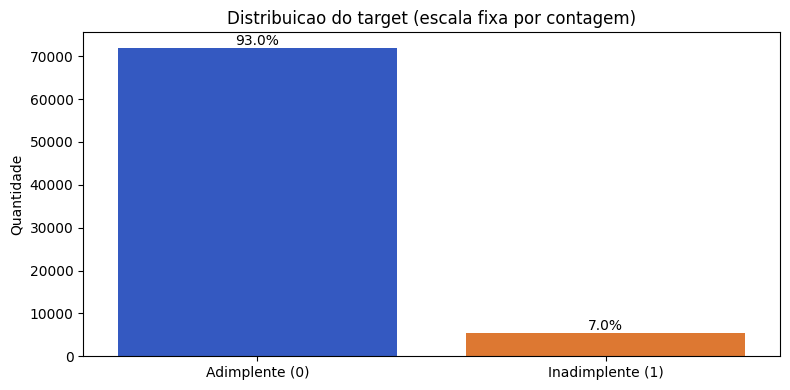

In [11]:
target_counts = train[TARGET_COL].value_counts(dropna=False).sort_index()
target_props = train[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index()

print('Contagem do target:')
display(target_counts.to_frame('count'))

print('Proporção do target:')
display((target_props * 100).round(2).astype(str).to_frame('pct_%'))

plot_df = pd.DataFrame({
    'classe': ['Adimplente (0)', 'Inadimplente (1)'],
    'count': [int(target_counts.get(0, 0)), int(target_counts.get(1, 0))],
})
plot_df['pct'] = plot_df['count'] / plot_df['count'].sum()

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=plot_df, x='classe', y='count', palette=['#1D4ED8', '#F97316'])
for i, row in plot_df.iterrows():
    ax.text(i, row['count'], f"{row['pct']*100:.1f}%", há='center', va='bottom', fontsize=10)
ax.set_title('Distribuição do target (escala fixa por contagem)')
ax.set_ylabel('Quantidade')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


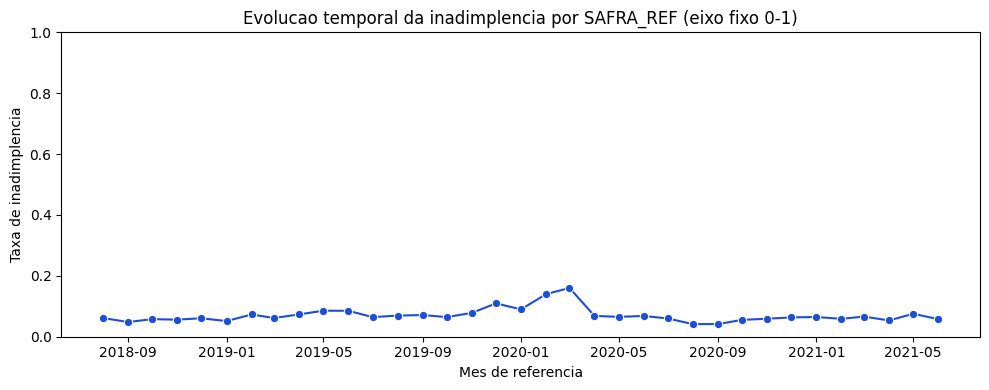

In [12]:
tmp = train.dropna(subset=['SAFRA_REF']).copy()
tmp['REF_MONTH'] = tmp['SAFRA_REF'].dt.to_period('M').dt.to_timestamp()
rate_month = tmp.groupby('REF_MONTH', as_index=False)[TARGET_COL].mean()

plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=rate_month, x='REF_MONTH', y=TARGET_COL, marker='o', color='#1D4ED8')
ax.set_ylim(0, 1)
ax.set_title('Evolução temporal da inadimplência por SAFRA_REF (eixo fixo 0-1)')
ax.set_ylabel('Taxa de inadimplência')
ax.set_xlabel('MÃªs de referência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
train_fe, test_fe = build_features(train, test)

new_cols = sorted(list(set(train_fe.columns) - set(train.columns)))
print(f'Novas features geradas: {len(new_cols)}')
display(pd.DataFrame({'new_feature': new_cols}).head(30))

print('Shape apos feature engineering:')
print('train_fe:', train_fe.shape)
print('test_fe :', test_fe.shape)


Novas features geradas: 6


,new_feature
0,MES
1,PRAZO_EMISSAO_VENCIMENTO
2,QTDE_ATRASOS_ANT
3,TEMPO_CADASTRO
4,TICKET_MEDIO_ANT
5,VALOR_RELATIVO_RENDA


Shape apos feature engineering:
train_fe: (77413, 24)
test_fe : (12264, 24)


Descrição estatística das variáveis numéricas principais:


,count,mean,std,min,5%,25%,50%,75%,95%,max
VALOR_A_PAGAR,76244.0000,46590.7772,46433.9296,0.1000,3263.2520,18765.3625,34758.6950,60933.8375,128337.5645,4400000.0000
RENDA_MES_ANTERIOR,71281.0000,291439.2175,213294.4406,105.0000,46088.0000,134054.0000,240502.0000,396250.0000,708470.0000,1682759.0000
VALOR_RELATIVO_RENDA,70210.0000,0.4262,5.1447,0.0000,0.0160,0.0676,0.1492,0.3358,1.1502,683.1219
QTDE_ATRASOS_ANT,77413.0000,7.3227,26.0391,0.0000,0.0000,0.0000,0.0000,3.0000,35.0000,300.0000
TICKET_MEDIO_ANT,77413.0000,45331.9348,28930.6337,0.0000,15639.4789,24752.0639,37597.1422,57910.0354,101790.1938,950000.0000
TEMPO_CADASTRO,77413.0000,3588.4977,2270.3903,0.0000,466.0000,1840.0000,3112.0000,5447.0000,7397.0000,7624.0000


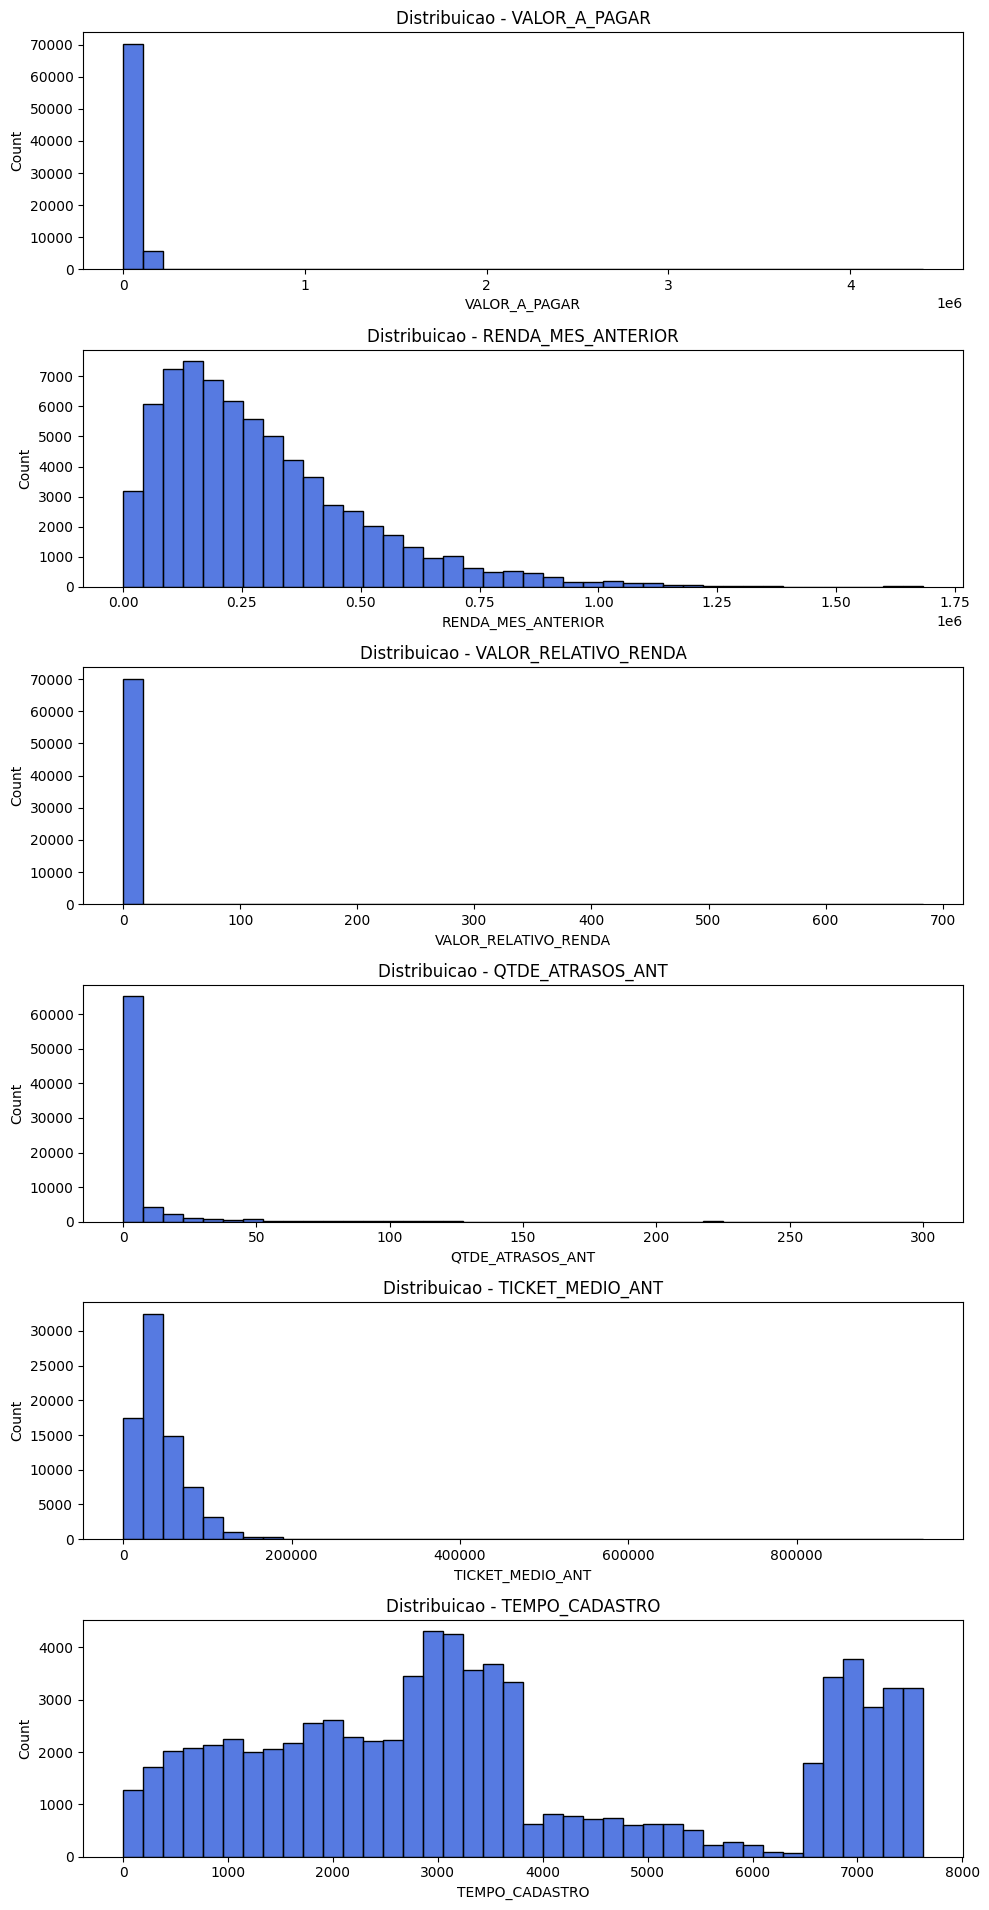

In [14]:
num_main = [
    'VALOR_A_PAGAR',
    'RENDA_MES_ANTERIOR',
    'VALOR_RELATIVO_RENDA',
    'QTDE_ATRASOS_ANT',
    'TICKET_MEDIO_ANT',
    'TEMPO_CADASTRO',
]
num_main = [c for c in num_main if c in train_fe.columns]

print('Descrição estatística das variáveis numéricas principais:')
display(train_fe[num_main].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

n = len(num_main)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2 * max(1, n)))
if n == 1:
    axes = [axes]
for ax, col in zip(axes, num_main):
    sns.histplot(train_fe[col].dropna(), bins=40, kde=False, ax=ax, color='#1D4ED8')
    ax.set_title(f'Distribuição - {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


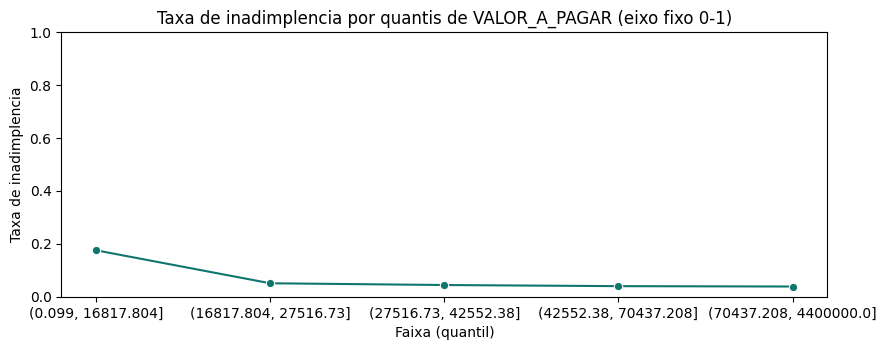

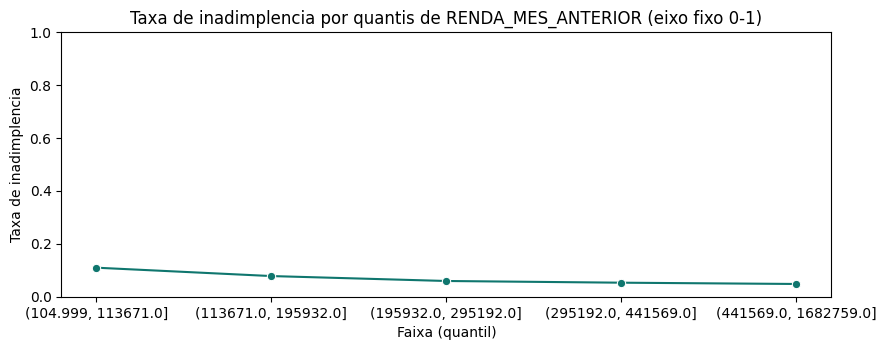

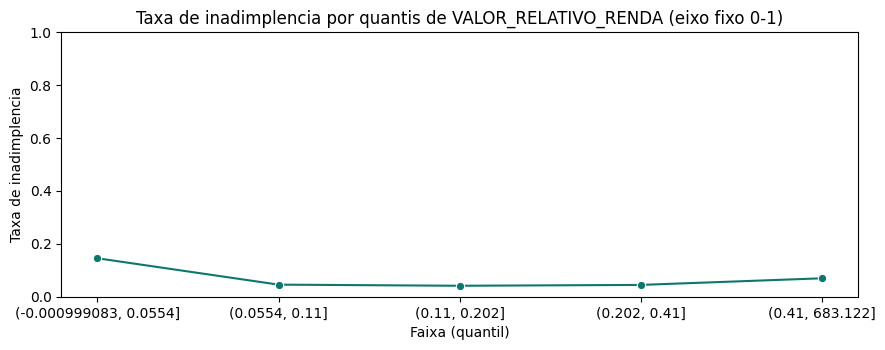

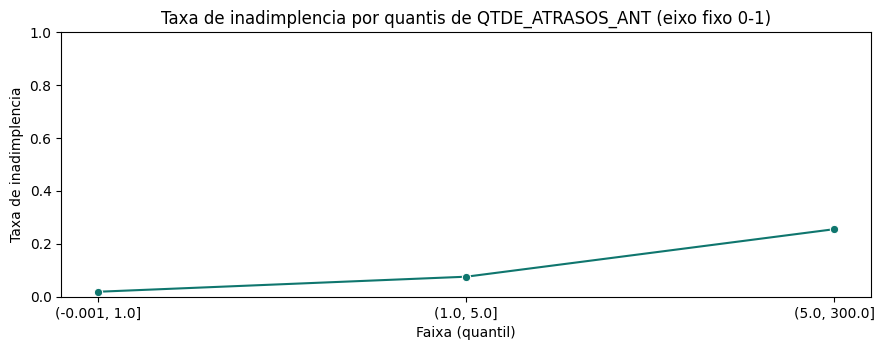

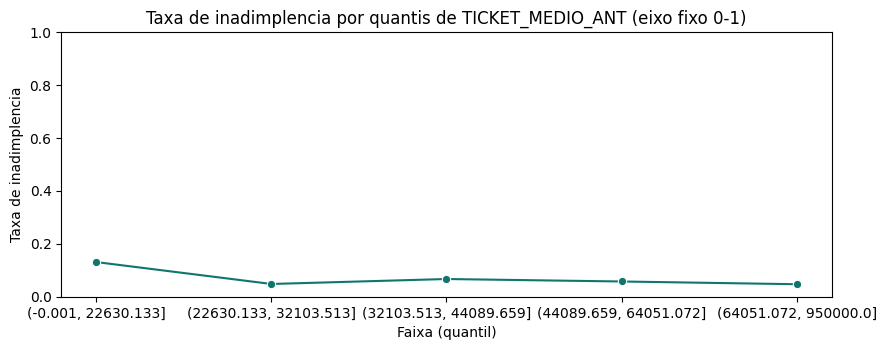

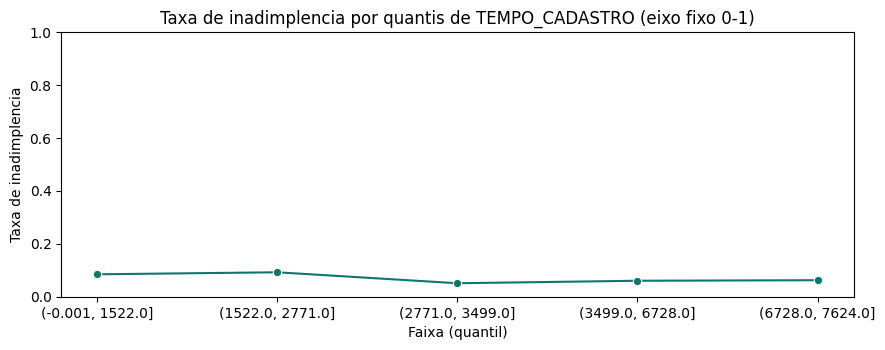

In [15]:
quantile_cols = [
    'VALOR_A_PAGAR',
    'RENDA_MES_ANTERIOR',
    'VALOR_RELATIVO_RENDA',
    'QTDE_ATRASOS_ANT',
    'TICKET_MEDIO_ANT',
    'TEMPO_CADASTRO',
]
quantile_cols = [c for c in quantile_cols if c in train_fe.columns]

for col in quantile_cols:
    qdf = delinquency_by_quantile(train_fe, col, q=5)
    if qdf.empty:
        continue
    plt.figure(figsize=(9, 3.6))
    ax = sns.lineplot(data=qdf, x='bucket', y='rate', marker='o', color='#0F766E')
    ax.set_ylim(0, 1)
    ax.set_title(f'Taxa de inadimplência por quantis de {col} (eixo fixo 0-1)')
    ax.set_ylabel('Taxa de inadimplência')
    ax.set_xlabel('Faixa (quantil)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


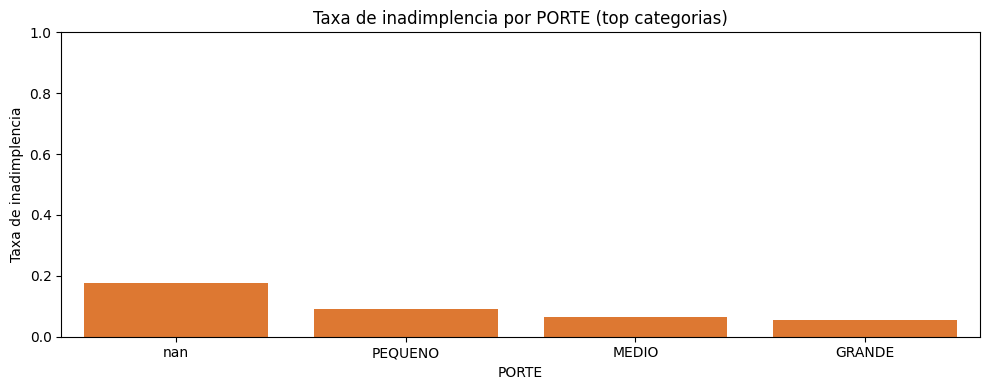

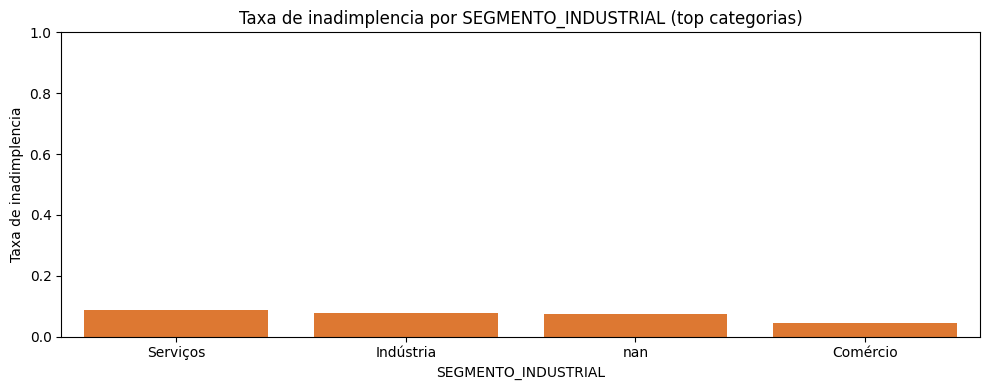

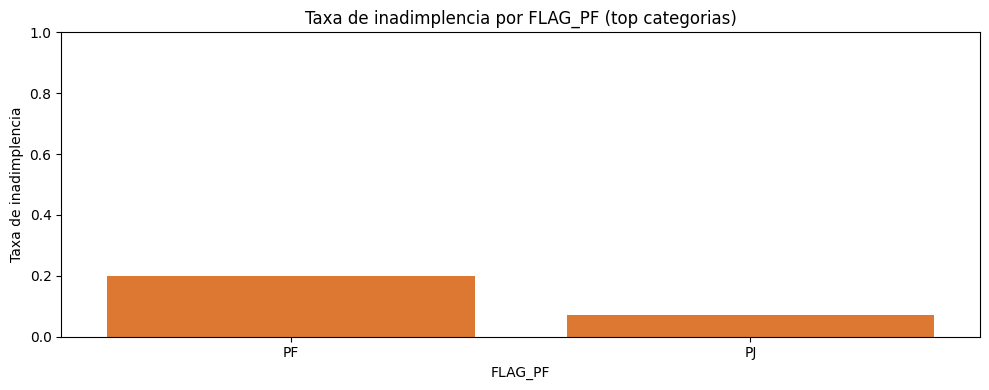

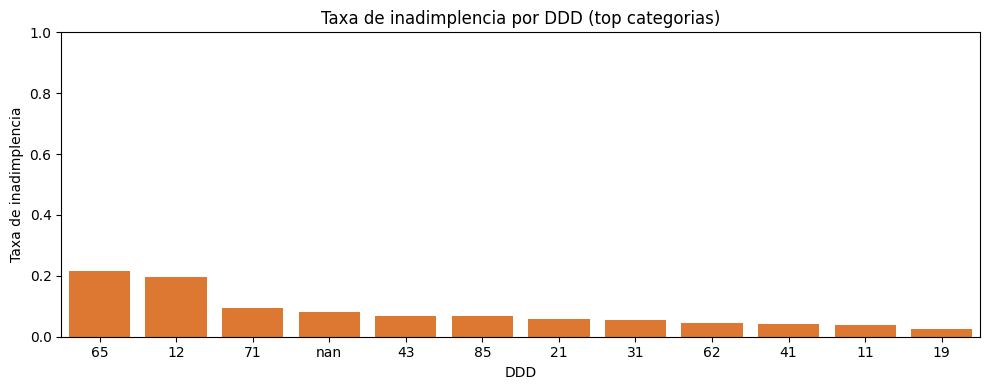

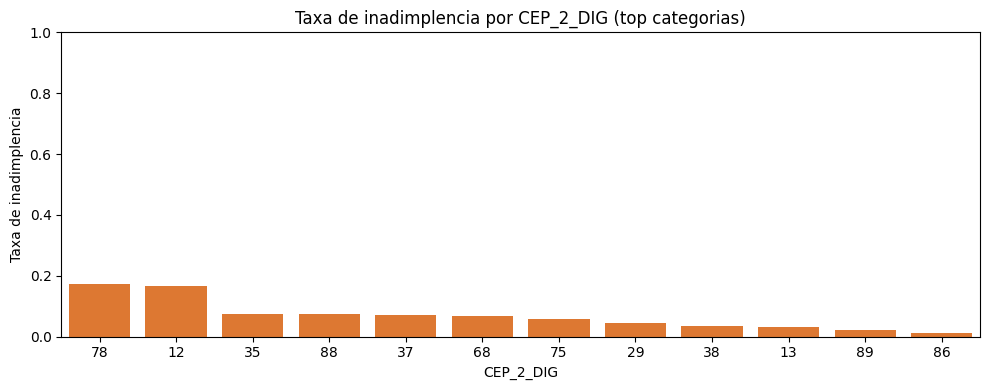

In [16]:
cat_cols = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'FLAG_PF', 'DDD', 'CEP_2_DIG']
cat_cols = [c for c in cat_cols if c in train_fe.columns]

for col in cat_cols:
    tmp = train_fe[[col, TARGET_COL]].copy()
    tmp[col] = tmp[col].astype(str).fillna('NaN')
    top = tmp[col].value_counts().head(12).index
    agg = (
        tmp[tmp[col].isin(top)]
        .groupby(col, observed=False)[TARGET_COL]
        .mean()
        .sort_values(ascending=False)
        .reset_index(name='delinq_rate')
    )
    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=agg, x=col, y='delinq_rate', color='#F97316')
    ax.set_ylim(0, 1)
    ax.set_title(f'Taxa de inadimplência por {col} (top categorias)')
    ax.set_ylabel('Taxa de inadimplência')
    ax.set_xlabel(col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


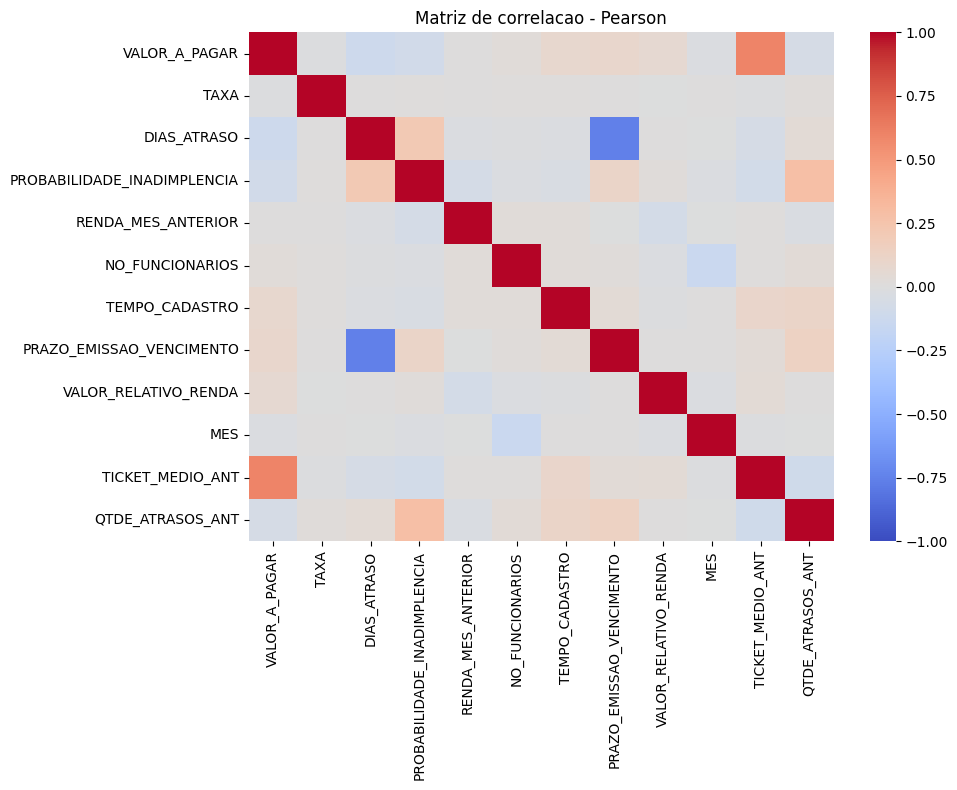

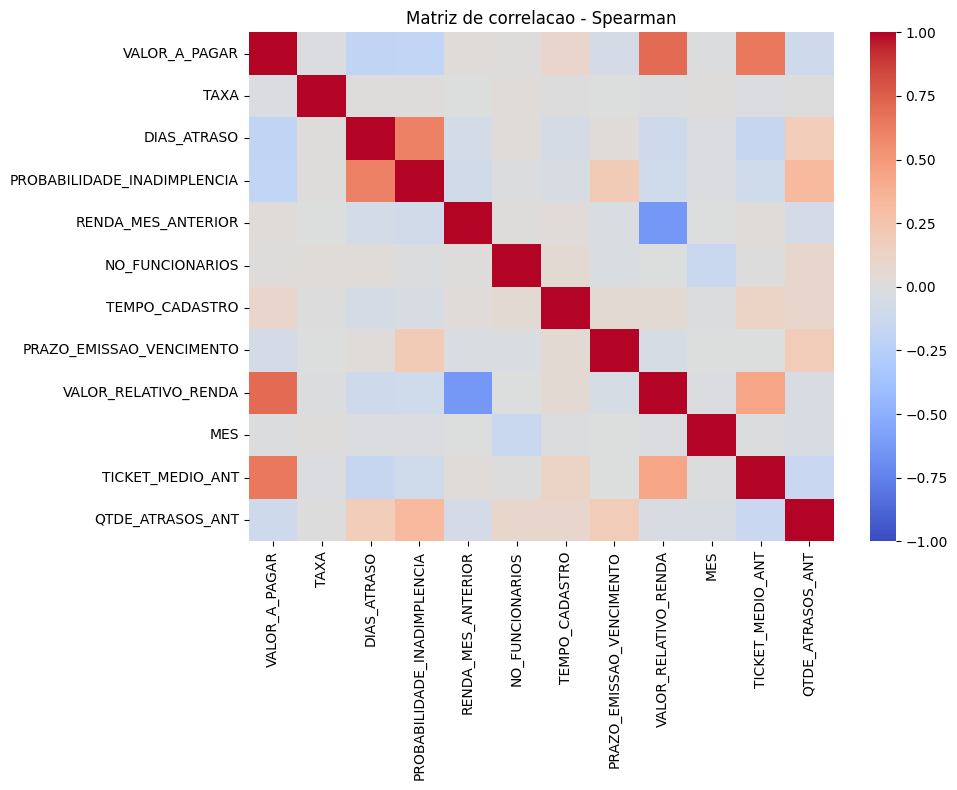

Maiores diferenças |Spearman - Pearson|:


,feature_a,feature_b,abs_spearman_minus_pearson
0,DIAS_ATRASO,PRAZO_EMISSAO_VENCIMENTO,0.7699
1,VALOR_A_PAGAR,VALOR_RELATIVO_RENDA,0.6438
2,RENDA_MES_ANTERIOR,VALOR_RELATIVO_RENDA,0.5685
3,VALOR_RELATIVO_RENDA,TICKET_MEDIO_ANT,0.3988
4,DIAS_ATRASO,PROBABILIDADE_INADIMPLENCIA,0.3979
5,VALOR_A_PAGAR,PRAZO_EMISSAO_VENCIMENTO,0.1595
6,DIAS_ATRASO,QTDE_ATRASOS_ANT,0.1402
7,PROBABILIDADE_INADIMPLENCIA,VALOR_RELATIVO_RENDA,0.1170
8,DIAS_ATRASO,VALOR_RELATIVO_RENDA,0.1093
9,DIAS_ATRASO,TICKET_MEDIO_ANT,0.0984


Interpretação curta: diferenças altas entre Spearman e Pearson sugerem relações não lineares ou monotônicas não lineares entre variáveis.


In [17]:
num_cols = [c for c in train_fe.columns if pd.api.types.is_numeric_dtype(train_fe[c]) and c != 'ID_CLIENTE']
num_cols = [c for c in num_cols if train_fe[c].notna().sum() > 0]

pear = train_fe[num_cols].corr(method='pearson')
spea = train_fe[num_cols].corr(method='spearman')

delta = (spea - pear).abs()
np.fill_diagonal(delta.values, 0.0)

plt.figure(figsize=(10, 8))
sns.heatmap(pear, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação - Pearson')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(spea, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação - Spearman')
plt.tight_layout()
plt.show()

pairs = (
    delta.where(np.triu(np.ones(delta.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)
pairs.columns = ['feature_a', 'feature_b', 'abs_spearman_minus_pearson']

print('Maiores diferenças |Spearman - Pearson|:')
display(pairs.head(15))

print('Interpretação curta: diferenças altas entre Spearman e Pearson sugerem relações não lineares ou monotônicas não lineares entre variáveis.')


## Principais hipoteses da EDA

- Variáveis de histórico de atraso, valor relativo a renda e ticket médio anterior apresentaram sinais relevantes de separação de risco.
- HÃ¡ evidÃªncias de nÃ£o linearidade (diferenças entre Pearson e Spearman e perfis por quantis com mudanÃ§as nÃ£o proporcionais).
- Variáveis categóricas segmentam risco de forma heterogÃªnea, com alguns grupos claramente mais arriscados.
- Esses sinais indicam que modelos baseados em árvores tendem a capturar melhor interações e padrões fragmentados do que modelos lineares puros.


## Conclusao da EDA

- As variáveis mais promissoras combinam comportamento histórico do cliente, intensidade financeira da cobranÃ§a e segmentação cadastral.
- A EDA guiou a modelagem para benchmark entre famílias de modelos (linear vs árvores), priorizando métricas adequadas para desbalanceamento.
- A proxima etapa e validar desempenho por PR-AUC/ROC-AUC e transformar threshold em politica operacional de priorizacao.
